In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# convert mnist image files into tensors of 4 dimensions (no of images, height, width, color channel)

transforms = transforms.ToTensor()

## load data 

In [3]:
# traininig data

train_data = datasets.MNIST(root='cnn_data',train= True, download=True, transform=transforms)


In [4]:
test_data = datasets.MNIST(root='cnn_data',train= False, download=True, transform=transforms)

In [5]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: cnn_data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [6]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: cnn_data
    Split: Test
    StandardTransform
Transform: ToTensor()

## convoultion and pooling thorugh one image

In [7]:
# create a small batch size for images -> 10

train_loader = DataLoader(train_data, batch_size=10, shuffle=True)
test_loader = DataLoader(test_data, batch_size=10, shuffle=False)

In [8]:
#define convolutional model
#describe convolutional layer and what its doing (2 layers)
#example

conv1 = nn.Conv2d(1, 6, 3, 1)  #input, output, kernal, stride
conv2 = nn.Conv2d(6, 16, 3, 1)

In [9]:
#grab 1 mnist image
for i, (X_Train, y_train) in enumerate(train_data):
    break

In [10]:
X_Train.shape

torch.Size([1, 28, 28])

In [11]:
x = X_Train.view(1,1,28,28)

In [12]:
# perdom our firt convolution

x = F.relu(conv1(x)) # releu -> rectified linear unit (activation function) 


In [13]:
# 1 is the image, 6 is the filters, 26 is the image size which reduced from 28x28 because of stide

x.shape

torch.Size([1, 6, 26, 26])

In [14]:
# pass through the pooling layer

x = F.max_pool2d(x, 2, 2) # kernel of 2 and stride of 2

In [15]:
# 26/2 = 13     

x.shape 

torch.Size([1, 6, 13, 13])

In [16]:
# do our second convolutional layer

x = F.relu(conv2(x))

In [17]:
x.shape 

torch.Size([1, 16, 11, 11])

In [18]:
# pooling layer 2

x = F.max_pool2d(x, 2, 2)

In [19]:
# 11/5 -> 5.5 but we have to round down, becase we cant can round up to invent new data

x.shape

torch.Size([1, 16, 5, 5])

In [20]:
((28-2) / 2 - 2) / 2

5.5

## Model Class

In [21]:
# model class

class ConvolutionalNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 3, 1)
        self.conv2 = nn.Conv2d(6, 16, 3, 1)
        # fully connected layer
        self.fc1 = nn.Linear(5*5*16, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    #forward function
    def forward(self, X):
        #first pass
        X = F.relu(self.conv1(X))
        X = F.max_pool2d(X, 2, 2) # 2x2 kernel and stride 2
        #second pass
        X = F.relu(self.conv2(X))
        X = F.max_pool2d(X, 2, 2)

        # re view to flatten it out
        X = X.view(-1, 16*5*5) # negative so we can vary batch size

        # fully connected layers
        X = F.relu(self.fc1(X))
        X = F.relu(self.fc2(X))
        X = self.fc3(X)
        # return F.log_softmax(X, dim=1)
        return X


In [22]:
# create instance of out model
torch.manual_seed(41)

In [23]:
model = ConvolutionalNetwork()
model

ConvolutionalNetwork(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [24]:
# loss function optmizer

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

## train and test model

In [25]:
import time
start_time = time.time()

# create variables to track things
epochs = 5
train_losses = []
test_losses = []
train_correct = []
test_correct = []

#for loop of epochs
for i in range(epochs):
    train_corr = 0
    test_corr = 0


    # train
    for b,(X_train, y_train) in enumerate(train_loader):
        b+=1 #start our batches at 1
        y_pred = model(X_train) #get prediction values from our training set. not flatten its 2d
        loss = criterion(y_pred, y_train) #compare predictions and correct answers 

        predicted = torch.max(y_pred.data, 1)[1]  # add number of correct predictions
        batch_corr = (predicted == y_train).sum() # how many we got correct from this batch
        train_corr += batch_corr #keeps track as we go along training

        # update parametetrs
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        #print results
        if b%600 == 0:
            print(f'Epoch: {i} Batch: {b} Loss: {loss.item()}')


    train_losses.append(loss)
    train_correct.append(train_corr)


    #test
    with torch.no_grad(): #so we dont update weights
        for b,(X_test, y_test) in enumerate(test_loader):
            y_val = model(X_test)
            predicted = torch.max(y_val.data, 1)[1]
            test_corr += (predicted == y_test).sum()


    loss = criterion(y_val, y_test)
    test_losses.append(loss)
    test_correct.append(test_corr)


current_time = time.time()
total_time = current_time - start_time
print(f'Training took: {total_time/60} mins')

Epoch: 0 Batch: 600 Loss: 0.16236217319965363
Epoch: 0 Batch: 1200 Loss: 0.1641411930322647
Epoch: 0 Batch: 1800 Loss: 0.5529826283454895
Epoch: 0 Batch: 2400 Loss: 0.13617022335529327
Epoch: 0 Batch: 3000 Loss: 0.005909767933189869
Epoch: 0 Batch: 3600 Loss: 0.41638413071632385
Epoch: 0 Batch: 4200 Loss: 0.0037092119455337524
Epoch: 0 Batch: 4800 Loss: 0.0024632560089230537
Epoch: 0 Batch: 5400 Loss: 0.04335440695285797
Epoch: 0 Batch: 6000 Loss: 0.0003619100316427648
Epoch: 1 Batch: 600 Loss: 0.003736626822501421
Epoch: 1 Batch: 1200 Loss: 0.30067330598831177
Epoch: 1 Batch: 1800 Loss: 0.0026166148018091917
Epoch: 1 Batch: 2400 Loss: 0.003824009792879224
Epoch: 1 Batch: 3000 Loss: 0.050153858959674835
Epoch: 1 Batch: 3600 Loss: 0.3020285964012146
Epoch: 1 Batch: 4200 Loss: 0.02147628925740719
Epoch: 1 Batch: 4800 Loss: 0.0009640451753512025
Epoch: 1 Batch: 5400 Loss: 0.00044654207886196673
Epoch: 1 Batch: 6000 Loss: 0.26091140508651733
Epoch: 2 Batch: 600 Loss: 0.11159493029117584
Ep

# visualization of loss at epochs

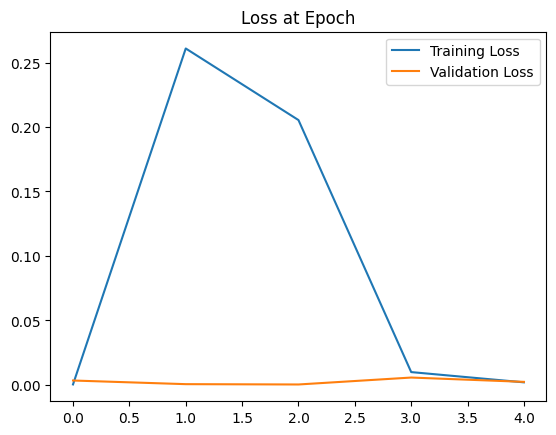

In [28]:
train_losses = [tl.item() for tl in train_losses]

plt.plot(train_losses, label = 'Training Loss')
plt.plot(test_losses, label = 'Validation Loss')
plt.title("Loss at Epoch")
plt.legend()

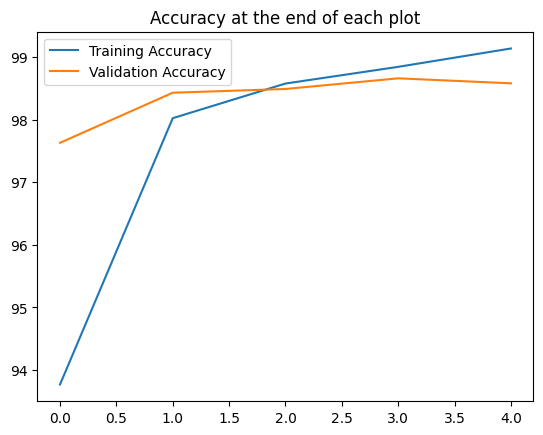

In [29]:
#graph the accuracey 

plt.plot([t/600 for t in train_correct], label = 'Training Accuracy')
plt.plot([t/100 for t in test_correct], label = 'Validation Accuracy')
plt.title('Accuracy at the end of each plot')
plt.legend()


In [30]:
test_load_all = DataLoader(test_data, batch_size=10000, shuffle = False)

In [31]:
with torch.no_grad():
    correct = 0
    for X_test, y_test in test_load_all:
        y_val = model(X_test)
        predicted = torch.max(y_val, 1)[1]
        correct += (predicted == y_test).sum()

In [33]:
correct.item()/len(test_data) * 100

98.58

# test on new data

In [35]:
test_data[2000]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.1922, 0.6235, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0471,
           0.4863, 0.4431, 0.3020, 0.0000, 

In [36]:
test_data[2000][0]

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.1922, 0.6235, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0471,
          0.4863, 0.4431, 0.3020, 0.0000, 0.0000, 0.0000,

In [ ]:
# reshape

test_data[2000][0].reshape(28,28)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.1922,
         0.6235, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0471, 0.4863, 0.4431,
         0.3020, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000

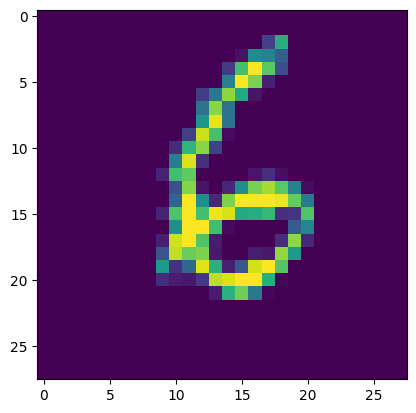

In [38]:
plt.imshow(test_data[2000][0].reshape(28,28))

In [39]:
#pass the image through out model
model.eval()
with torch.no_grad():
    new_predication = model(test_data[2000][0].view(1,1,28,28))

In [ ]:
#check results
new_predication

tensor([[ -3.0800,  -7.9564, -11.1089,  -8.2720,  -5.2167,  -3.1355,  10.0776,
         -19.3517,  -3.1644, -11.1414]])

In [ ]:
# select the max prob
new_predication.argmax()

tensor(6)